# Qualidade dos Dados — ELG, LRG, QSO

Diagnostico pre-treino. Decide os cortes de qualidade aplicados em `02_padding.ipynb`.

1. Distribuicao de redshift por classe
2. Distribuicao de S/N
3. ZWARNING flags
4. S/N vs zerr — S/N realmente prediz qualidade do z?
5. Cortes de qualidade propostos + impacto na amostra
6. Tabela resumo (figura 1 do paper)

## 1. Setup

In [10]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, h5py

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR
while not (PROJECT_ROOT / "config.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from config import paths_for, OBJECT_TYPES, RESULTS_DIR as PROJECT_RESULTS

OUT_DIR = PROJECT_RESULTS / "data_quality"
OUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_context("notebook")

## 2. Carregar catalogos

Le apenas o grupo `/catalog` de cada HDF5 bruto (`{OBJ}spectra_all.h5`). Campos opcionais (`line_flux`, fotometria IR) sao incluidos so se existirem.

In [11]:
WANTED = [
    "redshift", "zerr", "zwarning", "deltachi2", "chi2",
    "sn_median", "sn_median_all", "npixels",
    "g_mag", "r_mag", "i_mag", "z_mag", "gr_color", "ri_color",
    "w1_mag", "w1_w2_color", "line_flux",
]

def load_catalog(obj):
    p = paths_for(obj)["spectra_h5"]
    out = {}
    with h5py.File(p, "r") as f:
        cat = f["catalog"]
        for k in WANTED:
            if k in cat:
                out[k] = cat[k][:]
    return pd.DataFrame(out)

catalogs = {obj: load_catalog(obj) for obj in OBJECT_TYPES}
for obj, df in catalogs.items():
    print(f"{obj}: N={len(df):,}  cols={list(df.columns)}")

ELG: N=169,192  cols=['redshift', 'zerr', 'zwarning', 'deltachi2', 'chi2', 'sn_median', 'sn_median_all', 'npixels', 'g_mag', 'gr_color', 'line_flux']
LRG: N=167,635  cols=['redshift', 'zerr', 'zwarning', 'deltachi2', 'chi2', 'sn_median', 'sn_median_all', 'npixels', 'g_mag', 'r_mag', 'i_mag', 'z_mag', 'gr_color', 'ri_color', 'w1_mag', 'w1_w2_color', 'line_flux']


## 3. Distribuicao de redshift

In [ ]:
# Paleta colorblind-friendly (Wong 2011), consistente em todo o TCC
CLASS_COLORS = {"ELG": "#0072B2", "LRG": "#D55E00", "QSO": "#009E73"}

# Bins IGUAIS pras tres classes (comparacao justa)
zmin, zmax = 0.5, 2.3
bins = np.linspace(zmin, zmax, 70)

fig, ax = plt.subplots(figsize=(7, 4.2), dpi=150)

for obj, df in catalogs.items():
    z = df["redshift"]
    sns.histplot(
        z, bins=bins, ax=ax, stat="density",
        element="step", fill=True, alpha=0.15, linewidth=1.8,
        color=CLASS_COLORS[obj],
        label=f"{obj} (N={len(z):,})".replace(",", "."),
    )

ax.set_xlabel("Redshift espectroscopico $z$", fontsize=13)
ax.set_ylabel("Densidade", fontsize=13)
ax.set_xlim(zmin, zmax)
ax.set_ylim(bottom=0)

# Ticks pra dentro + minor ticks (estilo publicacao)
ax.tick_params(direction="in", which="both", labelsize=11, top=True, right=True)
ax.minorticks_on()

# Remove spines de cima e da direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=11, loc="upper right")
fig.tight_layout()

# Salva em vetor (PDF) pro paper + PNG pra preview
fig.savefig(OUT_DIR / "z_distribution.pdf", bbox_inches="tight", facecolor="white")
fig.savefig(OUT_DIR / "z_distribution.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


## 4. Distribuicao de S/N

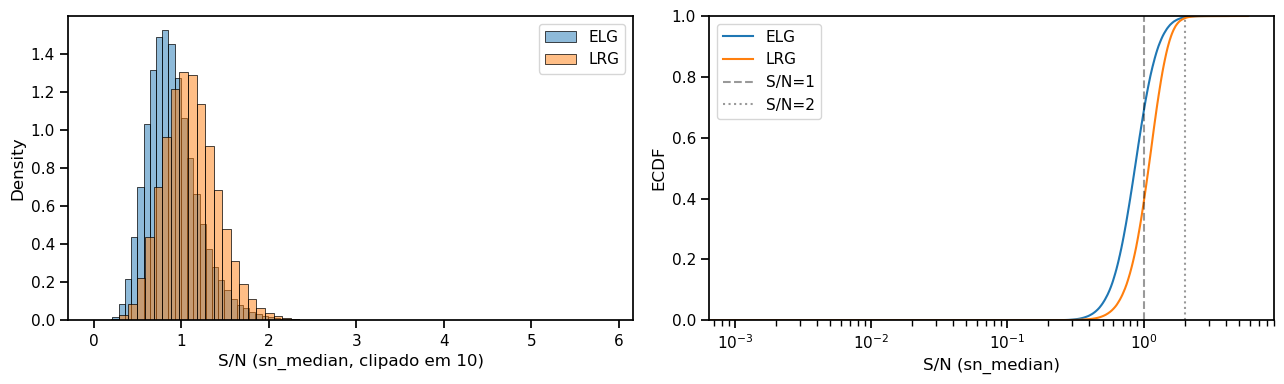

Quantis de S/N por classe:
      ELG   LRG
q10  0.56  0.72
q25  0.70  0.89
q50  0.86  1.09
q75  1.06  1.30
q90  1.28  1.51


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for obj, df in catalogs.items():
    snr = df["sn_median"].clip(0, 10)
    sns.histplot(snr, bins=60, label=obj, alpha=0.5, ax=axes[0], stat="density")
    sns.ecdfplot(df["sn_median"].clip(lower=1e-3), label=obj, ax=axes[1])
axes[0].set_xlabel("S/N (sn_median, clipado em 10)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[1].set_xlabel("S/N (sn_median)")
axes[1].set_ylabel("ECDF")
axes[1].set_xscale("log")
axes[1].axvline(1, ls="--", c="k", alpha=0.4, label="S/N=1")
axes[1].axvline(2, ls=":",  c="k", alpha=0.4, label="S/N=2")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "snr_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

qs = [0.1, 0.25, 0.5, 0.75, 0.9]
snr_q = pd.DataFrame(
    {obj: df["sn_median"].quantile(qs).values for obj, df in catalogs.items()},
    index=[f"q{int(q*100)}" for q in qs],
).round(2)
print("Quantis de S/N por classe:")
print(snr_q)

## 5. ZWARNING

`zwarning != 0` indica que o pipeline (redrock) marcou o redshift como duvidoso (`MANY_OUTLIERS`, `SMALL_DELTA_CHI2`, `Z_FITLIMIT`, etc.). Tipicamente nao usamos esses objetos no treino.

In [5]:
rows = []
for obj, df in catalogs.items():
    n = len(df)
    bad = int((df["zwarning"] != 0).sum())
    rows.append({"Classe": obj, "N": n, "zwarning!=0": bad, "frac_%": 100 * bad / n})
print(pd.DataFrame(rows).set_index("Classe").round(2))

             N  zwarning!=0  frac_%
Classe                             
ELG     169192            0    0.00
LRG     167635        34662   20.68


## 6. S/N vs zerr — S/N prediz a qualidade do z?

Se sim, `zerr/(1+z)` cai com S/N. Bins log em S/N, mediana e percentis 16/84. Se a curva for praticamente plana, S/N nao discrimina qualidade — nao serve como corte sozinho.

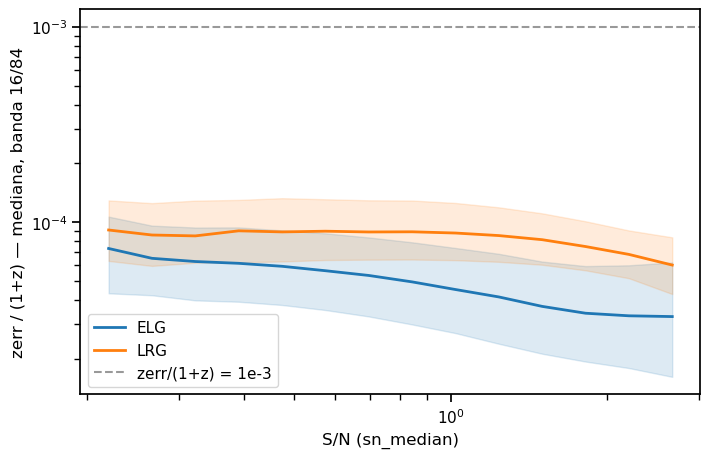

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
edges = np.geomspace(0.2, 20, 25)
centers = np.sqrt(edges[:-1] * edges[1:])

for obj, df in catalogs.items():
    if "zerr" not in df.columns:
        continue
    rel = (df["zerr"] / (1 + df["redshift"])).where(lambda s: s > 0)
    snr = df["sn_median"].where(df["sn_median"] > 0)
    med, lo, hi = [], [], []
    for a, b in zip(edges[:-1], edges[1:]):
        m = (snr >= a) & (snr < b) & rel.notna()
        if m.sum() < 30:
            med.append(np.nan); lo.append(np.nan); hi.append(np.nan)
            continue
        v = rel[m].values
        med.append(np.median(v)); lo.append(np.quantile(v, 0.16)); hi.append(np.quantile(v, 0.84))
    med, lo, hi = np.array(med), np.array(lo), np.array(hi)
    line, = ax.plot(centers, med, label=obj, lw=2)
    ax.fill_between(centers, lo, hi, alpha=0.15, color=line.get_color())

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("S/N (sn_median)")
ax.set_ylabel("zerr / (1+z) — mediana, banda 16/84")
ax.axhline(1e-3, ls="--", c="k", alpha=0.4, label="zerr/(1+z) = 1e-3")
ax.legend()
plt.savefig(OUT_DIR / "snr_vs_zerr.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Cortes de qualidade propostos

Avalia o impacto de cada corte cumulativo. Os cortes finais aplicados em `02_padding.ipynb` saem daqui.

- **C1**: `zwarning == 0`
- **C2**: + `zerr/(1+z) < 1e-3`
- **C3**: + `deltachi2 > 9`
- **C4**: + `sn_median > 0.5` (afrouxado p/ nao perder ELG/LRG inteiros)

In [7]:
def apply_cuts(df):
    n0 = len(df)
    m1 = df["zwarning"] == 0
    m2 = m1 & ((df["zerr"] / (1 + df["redshift"])) < 1e-3) if "zerr" in df else m1
    m3 = m2 & (df["deltachi2"] > 9) if "deltachi2" in df else m2
    m4 = m3 & (df["sn_median"] > 0.5) if "sn_median" in df else m3
    return [
        ("raw", n0),
        ("C1 zwarning==0", int(m1.sum())),
        ("C2 +zerr/(1+z)<1e-3", int(m2.sum())),
        ("C3 +deltachi2>9", int(m3.sum())),
        ("C4 +S/N>0.5", int(m4.sum())),
    ]

rows = []
for obj, df in catalogs.items():
    n0 = len(df)
    for label, n in apply_cuts(df):
        rows.append({"Classe": obj, "Corte": label, "N": n, "% retido": 100 * n / n0})
tab = pd.DataFrame(rows)
tab_pivot = tab.pivot(index="Corte", columns="Classe", values="N").reindex(
    ["raw", "C1 zwarning==0", "C2 +zerr/(1+z)<1e-3", "C3 +deltachi2>9", "C4 +S/N>0.5"]
)
print(tab_pivot)
tab.to_csv(OUT_DIR / "quality_cuts_impact.csv", index=False)

Classe                  ELG     LRG
Corte                              
raw                  169192  167635
C1 zwarning==0       169192  132973
C2 +zerr/(1+z)<1e-3  169190  132972
C3 +deltachi2>9      169190  132972
C4 +S/N>0.5          159759  132554


## 8. Tabela resumo (figura 1 do paper)

## 9. Para a figura 1 do paper

**Mensagem-chave**: a amostra eBOSS ELG/LRG e desafiadora **nao pelo target, mas pelo S/N do input**.

- O **target z** e essencialmente perfeito como rotulo de ML: `zerr / (1+z) ~ 1e-4` (≈ 30 km/s) para a quase totalidade dos objetos, com banda 16/84 sempre mais de uma ordem de grandeza abaixo do threshold de 1e-3.
- O **input flux** vive num regime de S/N mediano sub-unitario (ELG ~0.86, LRG ~1.09) — bem abaixo dos S/N tipicos (≳5–20) usados em trabalhos de ML em espectros.
- A curva `S/N vs zerr/(1+z)` e quase plana — o redrock ja extrai z preciso mesmo de espectros ruidosos via cross-correlation com templates (4000 A break, [OII] 3727).

**Implicacao para o paper**: a dificuldade nao esta em "limpar labels ruins", e sim em **construir um modelo capaz de aprender features espectrais sob ruido dominante**. Isso justifica:
- a escolha de S/N como variavel de estudo central (notebook 17, `low_snr_robustness`);
- o uso de cortes de qualidade minimos (`zwarning == 0`) — qualquer corte mais agressivo descarta espectros cujo target e bom mas cujo input e dificil, exatamente o regime que queremos cobrir.

In [8]:
rows = []
for obj, df in catalogs.items():
    rows.append({
        "Classe": obj,
        "N": len(df),
        "z_min": df["redshift"].min(),
        "z_max": df["redshift"].max(),
        "z_median": df["redshift"].median(),
        "S/N_median": df["sn_median"].median(),
        "zwarning!=0_%": 100 * (df["zwarning"] != 0).mean(),
    })
summary = pd.DataFrame(rows).set_index("Classe").round(3)
summary.to_csv(OUT_DIR / "dataset_summary.csv")
summary

,N,z_min,z_max,z_median,S/N_median,zwarning!=0_%
Classe,,,,,,
ELG,169192,0.6,1.1,0.832,0.863,0.000
LRG,167635,0.6,1.0,0.737,1.087,20.677
